In [ ]:
# Welcome to your new notebook
# Type here in the cell editor to add code!
# Read the 'dimcustomer' table from the Lakehouse
df = spark.read.table("AIAdvWks_Lakehouse.dimcustomer")

# Remove duplicate rows
df_no_duplicates = df.dropDuplicates()

# Save the result to a new table named 'dimcustomerwdr'
df_no_duplicates.write.mode("overwrite").saveAsTable("AIAdvWks_Lakehouse.dimcustomerwdr")

StatementMeta(, 98a56042-dd2e-4d82-963e-6e03355a234c, 3, Finished, Available, Finished)

In [ ]:
# Load the table 'dimcustomerwdr' from the Lakehouse
df = spark.read.table("AIAdvWks_Lakehouse.dimcustomerwdr")

# Display the top 10 rows
display(df.limit(10))

StatementMeta(, 98a56042-dd2e-4d82-963e-6e03355a234c, 5, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 05a938f1-8b12-43e3-b241-6ec37cbe4aaf)

StatementMeta(, 98a56042-dd2e-4d82-963e-6e03355a234c, 10, Finished, Available, Finished)

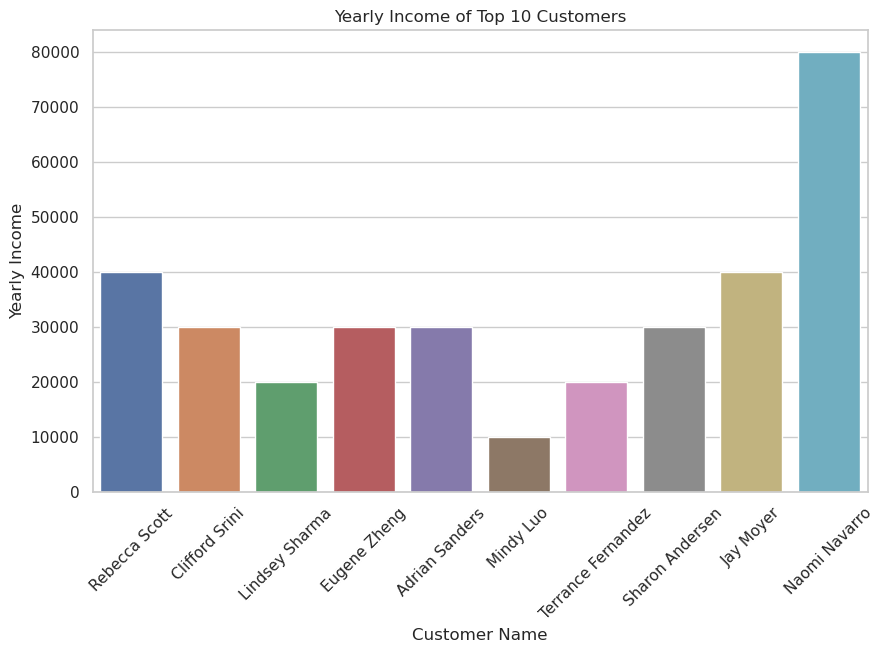

<Figure size 1000x600 with 0 Axes>

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Load the top 10 rows from the Lakehouse table and convert to pandas DataFrame
df = spark.read.table("AIAdvWks_Lakehouse.dimcustomerwdr").limit(10).toPandas()

# Create a new column combining FirstName and LastName
df["CustomerName"] = df["FirstName"].fillna('') + " " + df["LastName"].fillna('')

# Set the style for the plots
sns.set(style="whitegrid")

# Bar plot for YearlyIncome
plt.figure(figsize=(10, 6))
sns.barplot(x="CustomerName", y="YearlyIncome", data=df)
plt.title("Yearly Income of Top 10 Customers")
plt.xlabel("Customer Name")
plt.ylabel("Yearly Income")
plt.xticks(rotation=45)
display(plt.gcf())
plt.clf()


StatementMeta(, 98a56042-dd2e-4d82-963e-6e03355a234c, 11, Finished, Available, Finished)

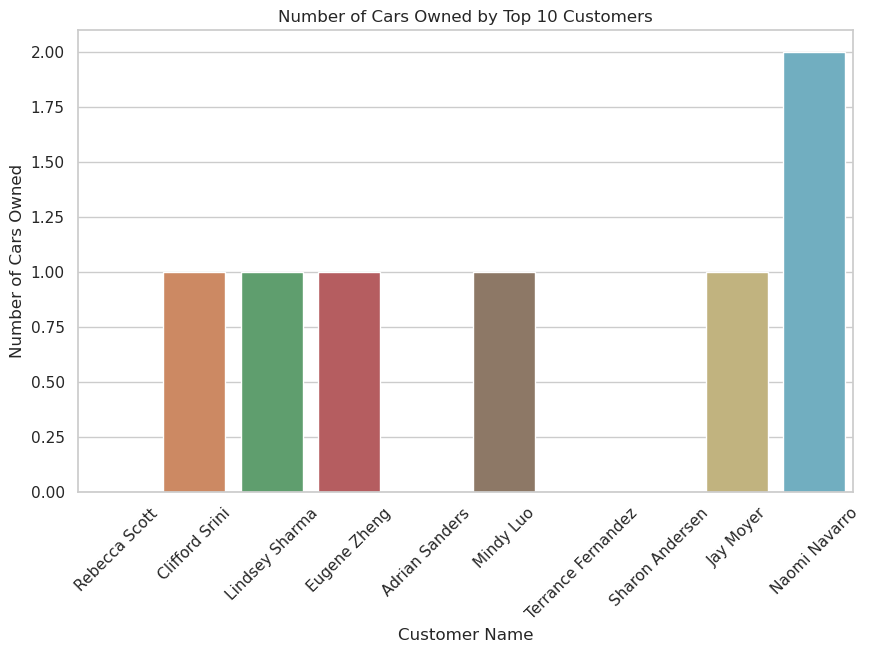

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Bar plot for NumberCarsOwned
plt.figure(figsize=(10, 6))
sns.barplot(x="CustomerName", y="NumberCarsOwned", data=df)
plt.title("Number of Cars Owned by Top 10 Customers")
plt.xlabel("Customer Name")
plt.ylabel("Number of Cars Owned")
plt.xticks(rotation=45)
display(plt.gcf())
plt.clf()



StatementMeta(, 98a56042-dd2e-4d82-963e-6e03355a234c, 13, Finished, Available, Finished)

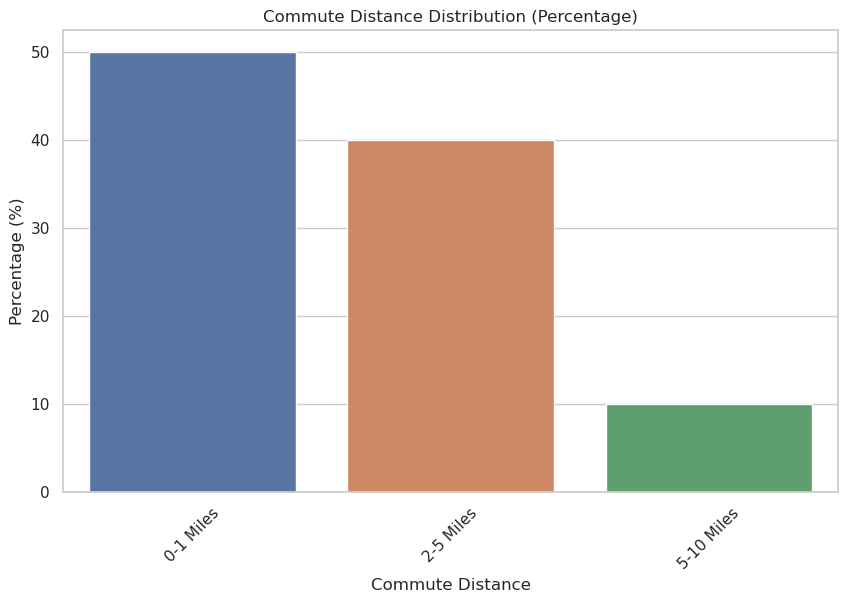

<Figure size 1000x600 with 0 Axes>

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Load the top 10 rows from the Lakehouse table and convert to pandas DataFrame
df = spark.read.table("AIAdvWks_Lakehouse.dimcustomerwdr").limit(10).toPandas()

# Calculate percentage distribution of CommuteDistance
commute_counts = df["CommuteDistance"].value_counts(normalize=True) * 100
commute_df = commute_counts.reset_index()
commute_df.columns = ["CommuteDistance", "Percentage"]

# Set the style for the plot
sns.set(style="whitegrid")

# Bar plot for CommuteDistance percentage
plt.figure(figsize=(10, 6))
sns.barplot(x="CommuteDistance", y="Percentage", data=commute_df)
plt.title("Commute Distance Distribution (Percentage)")
plt.xlabel("Commute Distance")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
display(plt.gcf())
plt.clf()
